In [28]:
import numpy as np
import matplotlib.pyplot as plt
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [29]:
import matplotlib.pyplot as plt
from dreimac import ToroidalCoords, GeometryExamples, CircleMapUtils
from persim import plot_diagrams

In [30]:
def find_partition_for_cocycle(tc, cocycle_idx, r_cover=None, std_thresh=0.01):
    harm_reps = tc._harm_reps
    from dreimac.utils import CohomologyUtils
    r_cover = tc._r_cover if r_cover is None else r_cover
    theta = CohomologyUtils.one_cocycle_to_matrix(dist_mat=tc._dist_land_land, 
                                                threshold=tc._r_cover,
                                                lookup_table=tc._cns_lookup_table,
                                                n_points = tc._n_landmarks,
                                                cocycle_as_vector=harm_reps[cocycle_idx])
    bad_idx = []
    good_idx = []
    for i in range(len(theta)):
        vector = theta[i,:]
        nonzero_vector = vector[vector!=0]

        if len(nonzero_vector) == 0:
            bad_idx.append(i)
        else:
            diff = np.std(nonzero_vector)
            if diff <= std_thresh:
                bad_idx.append(i)
            else:
                good_idx.append(i)
    return good_idx, bad_idx


# Theta shape

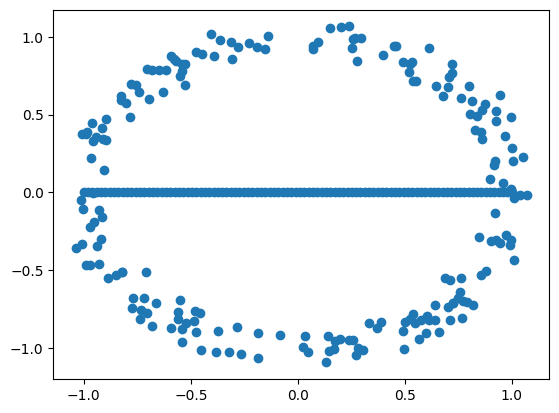

In [31]:
X1 = GeometryExamples.noisy_circle(n_samples=200, noise_size=0.2)
X2 = np.zeros(shape=(100, 2))
X2[:, 0] = np.linspace(-1, 1, num =100)
X = np.vstack([X1, X2])
plt.scatter(X[:,0], X[:,1])

In [32]:
tc = ToroidalCoords(X, n_landmarks=len(X))

In [33]:
tc_theta = tc.get_coordinates(cocycle_idxs=[0,1])

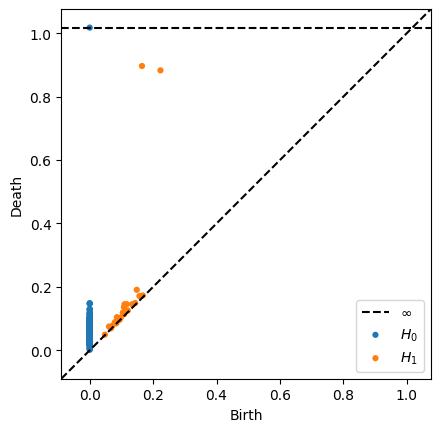

In [34]:
plot_diagrams(tc.dgms_)

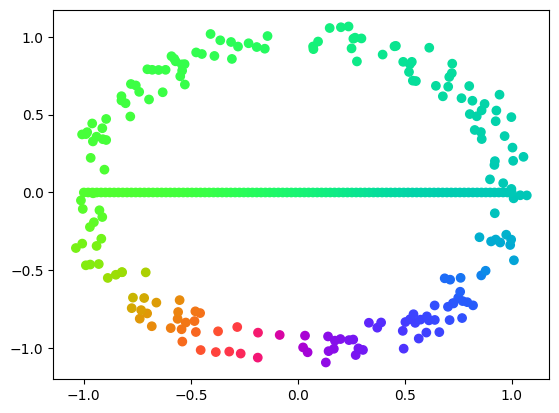

In [35]:
plt.scatter(X[:,0], X[:,1], c = CircleMapUtils.to_sinebow(tc_theta[0,:]))
#plt.scatter(X[tc._idx_land, 0], X[tc._idx_land, 1], color='black')

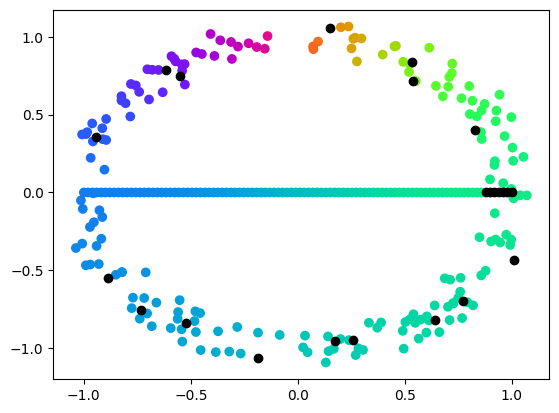

In [36]:
good_idx, bad_idx = find_partition_for_cocycle(tc, cocycle_idx= 1, std_thresh=0.001)
plt.scatter(X[good_idx,0], X[good_idx,1], c = CircleMapUtils.to_sinebow(tc_theta[1,good_idx]))
plt.scatter(X[bad_idx,0], X[bad_idx,1], c= 'black')

# Wedge of Circles

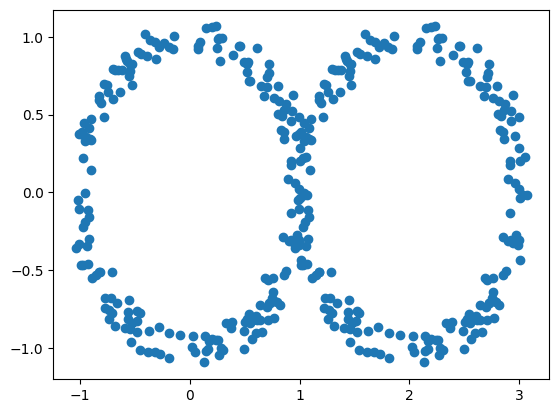

In [37]:
circ1 = GeometryExamples.noisy_circle(n_samples=200, noise_size=0.2)
circ2 = GeometryExamples.noisy_circle(n_samples=200, noise_size=0.2)
circ2[:,0] = circ2[:,0] + 2
X = np.vstack([circ1, circ2])
plt.scatter(X[:,0], X[:,1])

In [38]:
tc = ToroidalCoords(X, n_landmarks=400)
tc_theta = tc.get_coordinates(perc=0.15,cocycle_idxs=[0,1])

In [39]:
id_land = tc._idx_land

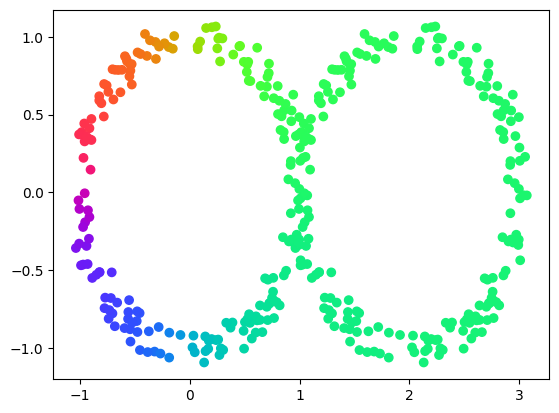

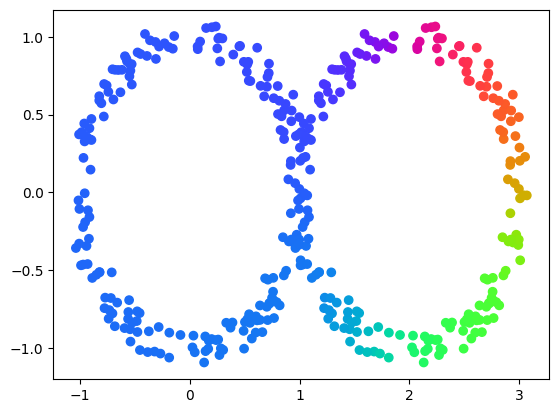

In [40]:
plt.scatter(X[:,0], X[:,1], c=CircleMapUtils.to_sinebow(tc_theta[0,:]))
#plt.scatter(X[id_land,0], X[id_land,1], c="black")
plt.show()
plt.scatter(X[:,0], X[:,1], c=CircleMapUtils.to_sinebow(tc_theta[1,:]))

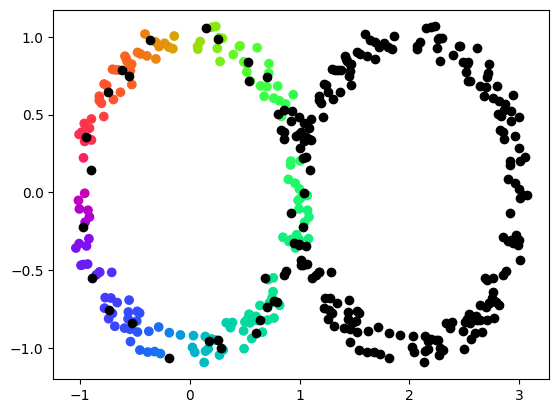

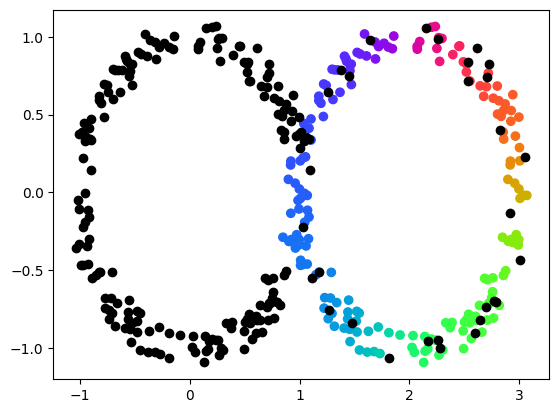

In [41]:
for id in [0,1]:
    good_idx, bad_idx = find_partition_for_cocycle(tc, cocycle_idx=id, std_thresh=0.01)
    plt.scatter(X[good_idx,0], X[good_idx,1], c = CircleMapUtils.to_sinebow(tc_theta[id,good_idx]))
    plt.scatter(X[bad_idx,0], X[bad_idx,1], c= 'black')
    plt.show()

# Sphere wedge circle

In [ ]:
import plotly.graph_objects as go

n_data = 400
theta = 2*np.pi*np.random.rand(n_data)
phi = np.pi*np.random.rand(n_data)
data = np.zeros((3,n_data))
data[0] = 2*np.cos(theta)*np.sin(phi) - 4
data[1] = 2*np.sin(theta)*np.sin(phi) - 0
data[2] = 2*np.cos(phi) - 0

beta = 2*np.pi * np.random.rand(n_data)
atad = np.zeros((3,n_data))
atad[0] = 2*np.cos(beta)
atad[1] = 2*np.sin(beta)
atad[2] = 0

data = np.hstack([data,atad])
#add noise
data += 0.2 * np.random.randn(*data.shape)

# Plot the data 
fig = go.Figure(data=[go.Scatter3d(
    x=data[0], y=data[1], z=data[2], 
    mode ='markers', 
    marker=dict(size = 1.5 , color = 'grey'))])
X = data.T
fig.update_layout( width=900, height=450)
fig.show()

In [ ]:
import plotly.express as px
tc = ToroidalCoords(X, n_landmarks=len(X))
tc_theta = tc.get_coordinates(cocycle_idxs=[0])
px.scatter_3d(x=X[tc._idx_land,0], y=X[tc._idx_land,1], z=X[tc._idx_land,2])

In [ ]:
import plotly.express as px
good_idx, bad_idx = find_partition_for_cocycle(tc, cocycle_idx= 0, r_cover=np.inf, std_thresh=0.1)
print(len(good_idx))
print(len(bad_idx))

0
800


In [ ]:

fig = go.Figure(data=[go.Scatter3d(
    x=X[good_idx, 0], y=X[good_idx, 1], z=X[good_idx, 2], 
    mode ='markers', 
    marker=dict(size = 3 , color = CircleMapUtils.to_sinebow(tc_theta[0][good_idx]))),
    go.Scatter3d(
    x=X[bad_idx, 0], y=X[bad_idx, 1], z=X[bad_idx, 2], 
    mode ='markers', 
    marker=dict(size = 3 , color = 'gray'))
    ])

fig.update_layout( width=900, height=450)
fig.show()

# Genus 2 Surface

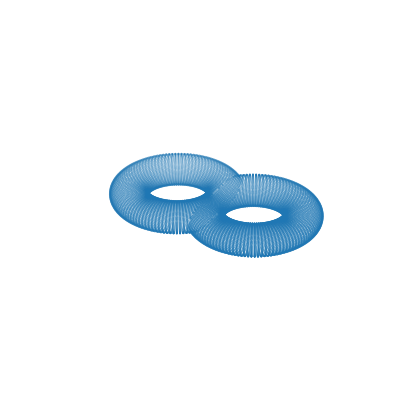

In [77]:
import matplotlib.pyplot as plt
from dreimac import CircularCoords, ToroidalCoords, GeometryExamples, PlotUtils, CircleMapUtils
from persim import plot_diagrams
X = GeometryExamples.genus_two_surface()

fig = plt.figure(figsize=(4,4))
ax = fig.add_subplot(projection="3d")
ax.scatter(X[:,0], X[:,1], X[:,2], s=0.1)
PlotUtils.set_axes_equal(ax) ; plt.axis("off") ; fig.subplots_adjust(top=1, bottom=0, left=0, right=1)

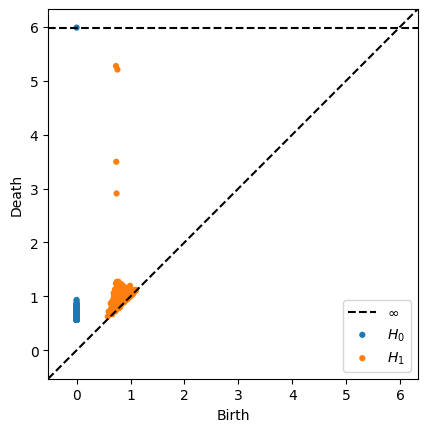

In [78]:
n_landmarks = 1200

tc = ToroidalCoords(X, n_landmarks=n_landmarks)
plot_diagrams(tc._dgms)

In [79]:
cohomology_classes = [0, 1, 2, 3]
toroidal_coords = tc.get_coordinates(cocycle_idxs=cohomology_classes)

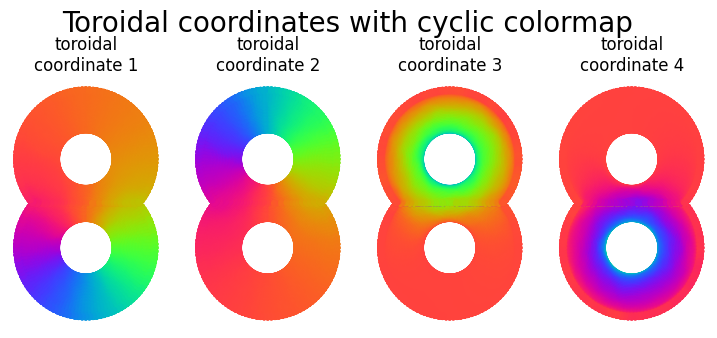

In [80]:
fig = plt.figure(figsize=(9,4))
fig.suptitle("Toroidal coordinates with cyclic colormap", fontsize=20)
for i, coordinate in enumerate(toroidal_coords):
    plt.subplot(1, len(toroidal_coords), i + 1)
    plt.scatter(X[:, 1], X[:, 0], s=20, c=CircleMapUtils.to_sinebow(CircleMapUtils.center(coordinate)))
    plt.title("toroidal\ncoordinate " + str(i+1))
    plt.gca().set_aspect("equal") ; _ = plt.axis("off")

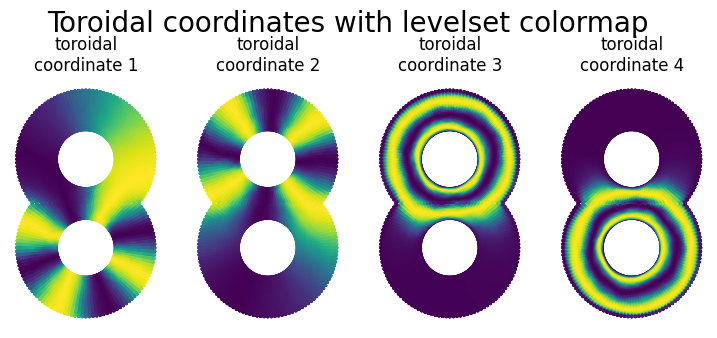

In [81]:
fig = plt.figure(figsize=(9, 4))
fig.suptitle("Toroidal coordinates with levelset colormap", fontsize=20)
for i, coordinate in enumerate(toroidal_coords):
    plt.subplot(1, len(toroidal_coords), i + 1)
    plt.scatter(
        X[:, 1],
        X[:, 0],
        s=2,
        c=CircleMapUtils.levelset_coloring(CircleMapUtils.center(coordinate)),
    )
    plt.title("toroidal\ncoordinate " + str(i + 1))
    plt.gca().set_aspect("equal")
    _ = plt.axis("off")

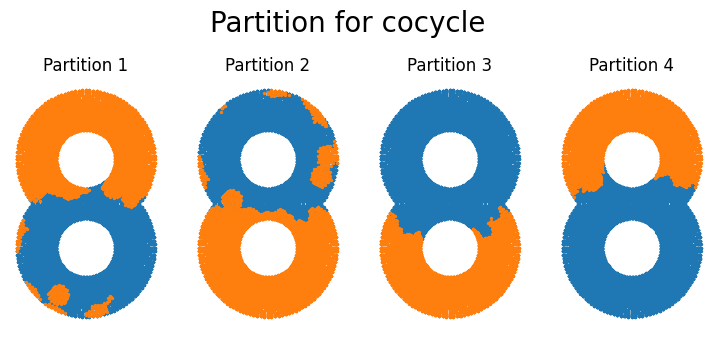

In [82]:

fig = plt.figure(figsize=(9, 4))
fig.suptitle("Partition for cocycle", fontsize=20)
for i, coordinate in enumerate(toroidal_coords):
    good_idx, bad_idx = find_partition_for_cocycle(tc, cocycle_idx=i, r_cover=tc._r_cover, std_thresh=0.012)
    landmarks = tc._idx_land
    good_landmarks = landmarks[good_idx]
    good_points = np.where([x in good_idx for x in tc.ball_indx])
    bad_points = np.where([x in bad_idx for x in tc.ball_indx])
    plt.subplot(1, len(toroidal_coords), i + 1)

    plt.scatter(
        X[good_points, 1],
        X[good_points, 0],
        s=2
    )
    plt.scatter(
        X[bad_points, 1],
        X[bad_points, 0],
        s=2
    )
    plt.title("Partition " + str(i + 1))
    plt.gca().set_aspect("equal")
    _ = plt.axis("off")

In [ ]:
good_points = np.asarray([]).astype(np.int64)
bad_points = np.asarray([]).astype(np.int64)
for i in [1,2]:
    good_idx, bad_idx = find_partition_for_cocycle(tc, cocycle_idx=i, r_cover=tc._r_cover, std_thresh=0.02)
    good_landmarks = landmarks[good_idx]
    good_points = np.append(good_points, np.where([x in good_idx for x in tc.ball_indx])) #Need union here
    bad_points = np.append(bad_points, np.where([x in bad_idx for x in tc.ball_indx]))
print(good_points)

fig = go.Figure(data=[go.Scatter3d(
    x=X[good_points, 0], y=X[good_points, 1], z=X[good_points, 2], 
    mode ='markers', 
    marker=dict(size = 3 , color = CircleMapUtils.to_sinebow(toroidal_coords[0][good_points]))),
    go.Scatter3d(
    x=X[bad_points, 0], y=X[bad_points, 1], z=X[bad_points, 2], 
    mode ='markers', 
    marker=dict(size = 3 , color = 'gray'))
    ])

fig.update_layout( width=900, height=400)
fig.show()



[ 1719  1820  1923 ... 16751 16752 16753]


In [84]:
landmarks = tc._idx_land
good_landmarks = landmarks[good_idx]
good_points = np.where([x in good_idx for x in tc.ball_indx])
bad_points = np.where([x in bad_idx for x in tc.ball_indx])

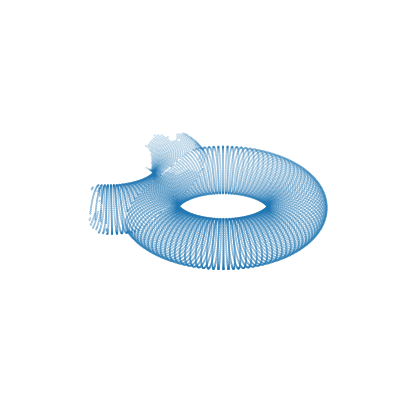

In [85]:
fig = plt.figure(figsize=(4,4))
ax = fig.add_subplot(projection="3d")
ax.scatter(X[good_points,0], X[good_points,1], X[good_points,2], s=0.1)
#ax.scatter(X[bad_points,0], X[bad_points,1], X[bad_points,2], s=0.1)
PlotUtils.set_axes_equal(ax) ; plt.axis("off") ; fig.subplots_adjust(top=1, bottom=0, left=0, right=1)